# SSVI -- Surface SVI (Gatheral & Jacquier 2014)

**SSVI** (Surface Stochastic Volatility Inspired) extends the SVI parameterization from a single smile to an entire volatility *surface* by introducing a joint parametrization across maturities.

## SSVI Total Variance

$$w(k, \theta_t) = \frac{\theta_t}{2}\left(1 + \rho\,\phi(\theta_t)\,k + \sqrt{(\phi(\theta_t)\,k + \rho)^2 + (1-\rho^2)}\right)$$

where
- $\theta_t = \sigma_{\text{ATM}}^2 \cdot T$ is the **ATM total variance** at maturity $T$
- $\rho \in (-1,1)$ controls the overall skew
- $\phi(\theta_t)$ controls how the smile shape evolves with the ATM level

## Power-Law $\phi$ (recommended)

$$\phi(\theta) = \frac{\eta}{\theta^\gamma (1+\theta)^{1-\gamma}}, \quad \eta > 0,\; \gamma \in (0,1)$$

**Butterfly-free** sufficient condition: $\eta(1 + |\rho|) \leq 4$

**Calendar-spread-free**: $\phi$ is non-increasing, which holds automatically for $\gamma \in (0,1)$.

## Notebook Sections
1. Power-law phi: shape and sensitivity
2. SSVI smile slices at multiple maturities
3. Parameter sensitivity: rho, eta, gamma
4. Arbitrage checks: butterfly-free and calendar-spread-free
5. Joint surface calibration to Heston implied vols
6. SSVI vs. SVI (per-smile) comparison

**Reference**: Gatheral, J. & Jacquier, A. (2014). Arbitrage-free SVI volatility surfaces. *Quantitative Finance*, 14(1), 59-71.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import foureng as fe
from foureng.surface.ssvi import (
    SSVIParams, ssvi_phi_power_law, ssvi_phi_heston,
    ssvi_total_variance, ssvi_implied_vol,
    ssvi_check_butterfly_free, ssvi_check_calendar_free,
    fit_ssvi_surface,
)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35})
print(f'foureng {fe.__version__}')

foureng 0.5.0


## 1. Power-Law Phi: Shape and Sensitivity

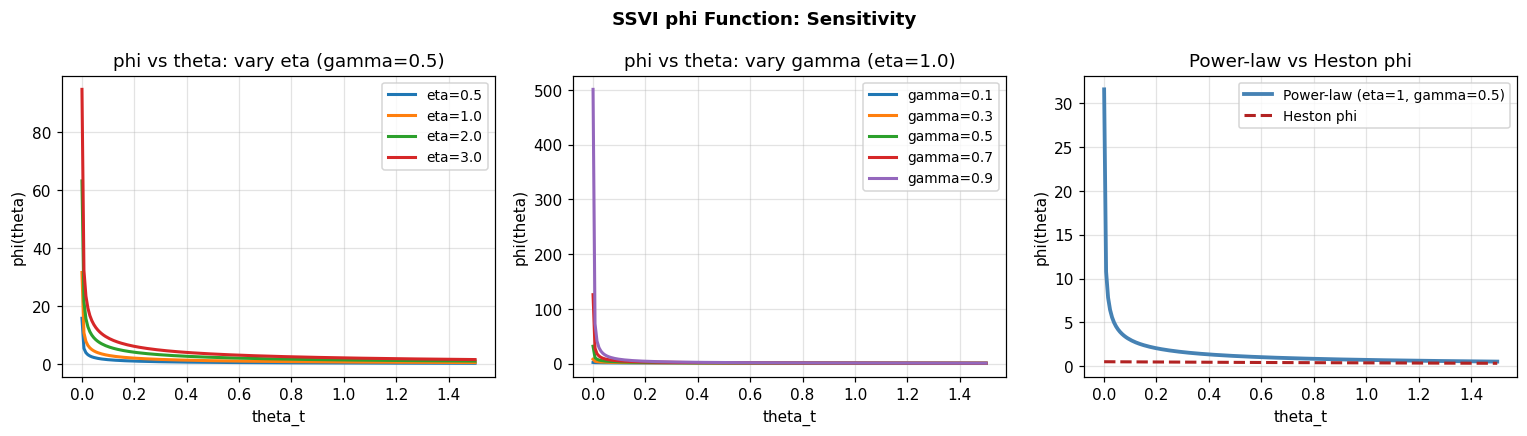

In [2]:
theta_arr = np.linspace(0.001, 1.5, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Vary eta
for eta in [0.5, 1.0, 2.0, 3.0]:
    axes[0].plot(theta_arr, ssvi_phi_power_law(theta_arr, eta=eta, gamma=0.5), 
                 lw=2, label=f'eta={eta}')
axes[0].set(title='phi vs theta: vary eta (gamma=0.5)', xlabel='theta_t', ylabel='phi(theta)')
axes[0].legend(fontsize=9)

# Vary gamma
for gamma in [0.1, 0.3, 0.5, 0.7, 0.9]:
    axes[1].plot(theta_arr, ssvi_phi_power_law(theta_arr, eta=1.0, gamma=gamma),
                 lw=2, label=f'gamma={gamma}')
axes[1].set(title='phi vs theta: vary gamma (eta=1.0)', xlabel='theta_t', ylabel='phi(theta)')
axes[1].legend(fontsize=9)

# Power-law vs Heston phi
axes[2].plot(theta_arr, ssvi_phi_power_law(theta_arr, eta=1.0, gamma=0.5),
             lw=2.5, color='steelblue', label='Power-law (eta=1, gamma=0.5)')
axes[2].plot(theta_arr, ssvi_phi_heston(theta_arr),
             lw=2, ls='--', color='firebrick', label='Heston phi')
axes[2].set(title='Power-law vs Heston phi', xlabel='theta_t', ylabel='phi(theta)')
axes[2].legend(fontsize=9)

fig.suptitle('SSVI phi Function: Sensitivity', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. SSVI Smile Slices at Multiple Maturities

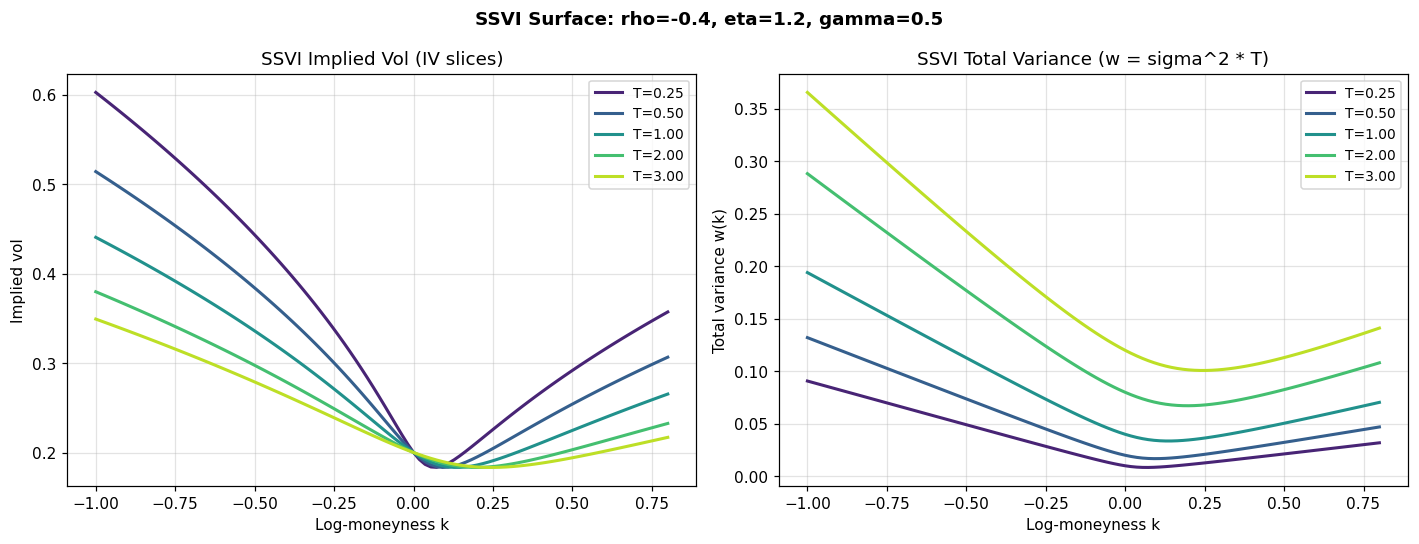

ATM IVs: ['0.2000', '0.2000', '0.2000', '0.2000', '0.2000']
Butterfly-free (sufficient): True
Calendar-free:               True


In [3]:
params = SSVIParams(rho=-0.4, eta=1.2, gamma=0.5)
sigma_atm = 0.20
MATS = np.array([0.25, 0.5, 1.0, 2.0, 3.0])
theta_t = sigma_atm**2 * MATS

k_arr = np.linspace(-1.0, 0.8, 100)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(MATS)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for T, th, c in zip(MATS, theta_t, colors):
    iv  = ssvi_implied_vol(k_arr, T, th, params)
    tv  = ssvi_total_variance(k_arr, th, params)
    axes[0].plot(k_arr, iv, color=c, lw=2, label=f'T={T:.2f}')
    axes[1].plot(k_arr, tv, color=c, lw=2, label=f'T={T:.2f}')

axes[0].set(title='SSVI Implied Vol (IV slices)', xlabel='Log-moneyness k', ylabel='Implied vol')
axes[0].legend(fontsize=9)

axes[1].set(title='SSVI Total Variance (w = sigma^2 * T)', xlabel='Log-moneyness k', ylabel='Total variance w(k)')
axes[1].legend(fontsize=9)

fig.suptitle(f'SSVI Surface: rho={params.rho}, eta={params.eta}, gamma={params.gamma}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'ATM IVs: {[f"{ssvi_implied_vol(np.array([0.0]), T, th, params)[0]:.4f}" for T, th in zip(MATS, theta_t)]}')
print(f'Butterfly-free (sufficient): {ssvi_check_butterfly_free(params)}')
print(f'Calendar-free:               {ssvi_check_calendar_free(theta_t, params)}')

## 3. Parameter Sensitivity: rho, eta, gamma

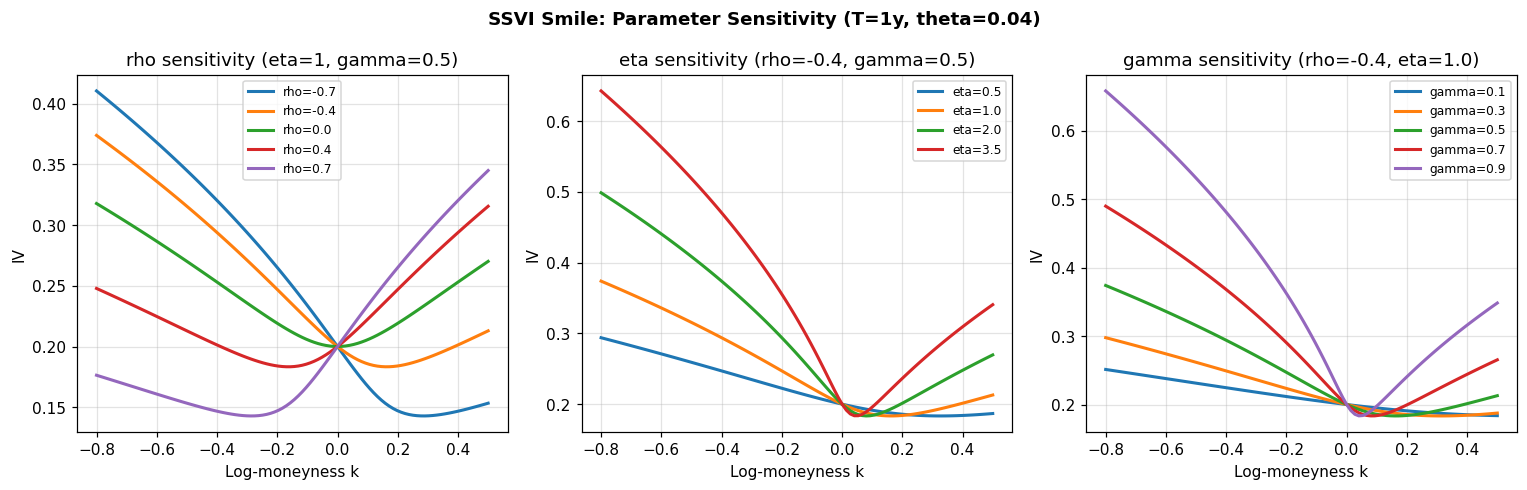

In [4]:
T_ref, th_ref = 1.0, 0.04   # 1-year, sigma_ATM = 20%
k_plot = np.linspace(-0.8, 0.5, 100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# rho sensitivity
for rho in [-0.7, -0.4, 0.0, 0.4, 0.7]:
    p = SSVIParams(rho=rho, eta=1.0, gamma=0.5)
    iv = ssvi_implied_vol(k_plot, T_ref, th_ref, p)
    axes[0].plot(k_plot, iv, lw=2, label=f'rho={rho:.1f}')
axes[0].set(title='rho sensitivity (eta=1, gamma=0.5)', xlabel='Log-moneyness k', ylabel='IV')
axes[0].legend(fontsize=8)

# eta sensitivity
for eta in [0.5, 1.0, 2.0, 3.5]:
    p = SSVIParams(rho=-0.4, eta=eta, gamma=0.5)
    iv = ssvi_implied_vol(k_plot, T_ref, th_ref, p)
    axes[1].plot(k_plot, iv, lw=2, label=f'eta={eta:.1f}')
axes[1].set(title='eta sensitivity (rho=-0.4, gamma=0.5)', xlabel='Log-moneyness k', ylabel='IV')
axes[1].legend(fontsize=8)

# gamma sensitivity
for gamma in [0.1, 0.3, 0.5, 0.7, 0.9]:
    p = SSVIParams(rho=-0.4, eta=1.0, gamma=gamma)
    iv = ssvi_implied_vol(k_plot, T_ref, th_ref, p)
    axes[2].plot(k_plot, iv, lw=2, label=f'gamma={gamma:.1f}')
axes[2].set(title='gamma sensitivity (rho=-0.4, eta=1.0)', xlabel='Log-moneyness k', ylabel='IV')
axes[2].legend(fontsize=8)

fig.suptitle('SSVI Smile: Parameter Sensitivity (T=1y, theta=0.04)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Arbitrage Checks

### Butterfly-Free Sufficient Condition: $\eta(1 + |\rho|) \leq 4$

### Calendar-Spread-Free: $\phi(\theta)$ non-increasing

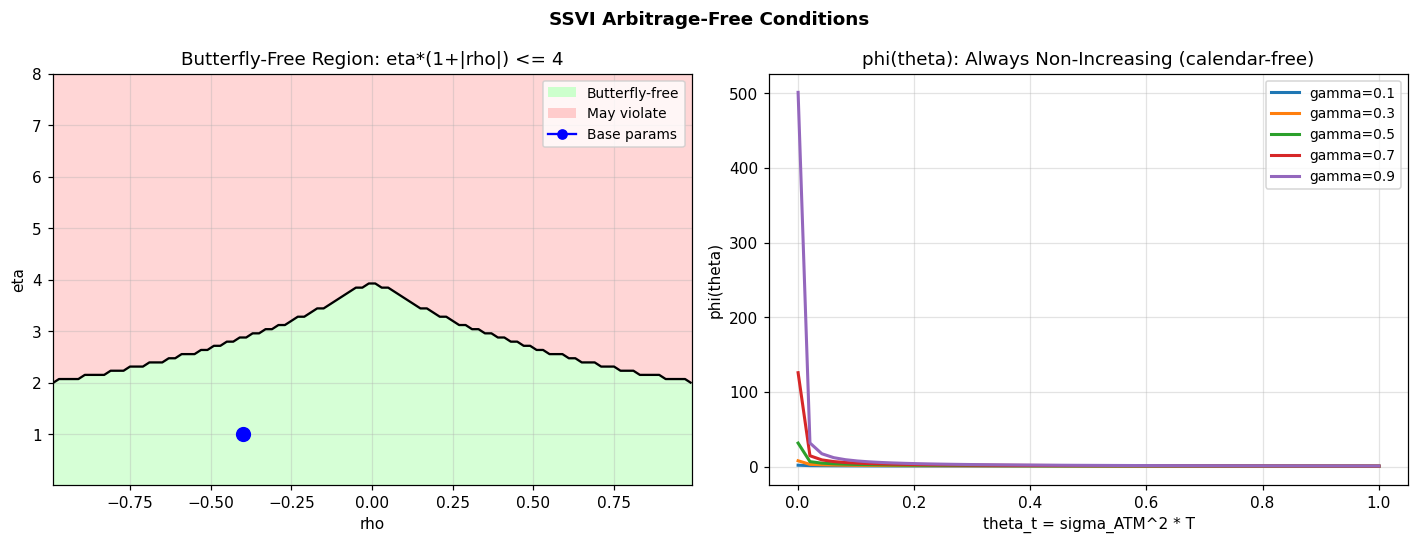

Base params: rho=-0.4, eta=1.0, gamma=0.5
  eta*(1+|rho|) = 1.400 <= 4.0: True
  Calendar-free (theta in [0.01,1.0]): True


In [5]:
# Map out butterfly-free region in (eta, rho) space
rho_arr = np.linspace(-0.99, 0.99, 100)
eta_arr = np.linspace(0.01, 8.0, 100)
RHO, ETA = np.meshgrid(rho_arr, eta_arr)
BF_FREE = ETA * (1.0 + np.abs(RHO)) <= 4.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cs = axes[0].contourf(RHO, ETA, BF_FREE.astype(float), levels=[0, 0.5, 1], 
                       colors=['#ffcccc', '#ccffcc'], alpha=0.8)
axes[0].contour(RHO, ETA, BF_FREE.astype(float), levels=[0.5], colors=['black'], linewidths=1.5)
axes[0].scatter([-0.4], [1.0], color='blue', s=80, zorder=5, label='Base params')
axes[0].set(title='Butterfly-Free Region: eta*(1+|rho|) <= 4',
            xlabel='rho', ylabel='eta')
axes[0].legend()
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='#ccffcc', label='Butterfly-free'),
                          Patch(facecolor='#ffcccc', label='May violate'),
                          plt.Line2D([0],[0], marker='o', color='blue', label='Base params')],
               fontsize=9)

# Calendar-free: show phi is non-increasing for different gamma
theta_t_demo = np.linspace(0.001, 1.0, 50)
for gamma in [0.1, 0.3, 0.5, 0.7, 0.9]:
    phi_vals = ssvi_phi_power_law(theta_t_demo, eta=1.0, gamma=gamma)
    axes[1].plot(theta_t_demo, phi_vals, lw=2, label=f'gamma={gamma:.1f}')
axes[1].set(title='phi(theta): Always Non-Increasing (calendar-free)',
            xlabel='theta_t = sigma_ATM^2 * T', ylabel='phi(theta)')
axes[1].legend(fontsize=9)

fig.suptitle('SSVI Arbitrage-Free Conditions', fontweight='bold')
plt.tight_layout()
plt.show()

# Verify base params
base = SSVIParams(rho=-0.4, eta=1.0, gamma=0.5)
print(f'Base params: rho={base.rho}, eta={base.eta}, gamma={base.gamma}')
print(f'  eta*(1+|rho|) = {base.eta*(1+abs(base.rho)):.3f} <= 4.0: {ssvi_check_butterfly_free(base)}')
print(f'  Calendar-free (theta in [0.01,1.0]): {ssvi_check_calendar_free(np.linspace(0.01, 1.0, 20), base)}')

## 5. Joint Surface Calibration to Heston Implied Vols

We generate a multi-maturity IV surface from the Heston model and fit SSVI jointly to all maturities.

In [6]:
# Heston model setup
S0  = 100.0
r   = 0.03
q   = 0.01
heston = fe.HestonParams(kappa=2.0, theta=0.04, nu=0.5, rho=-0.7, v0=0.04)
MATS_FIT = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
k_arr_fit = np.linspace(-0.7, 0.5, 41)

def heston_iv_smile(T):
    F = S0 * np.exp((r - q) * T)
    strikes = F * np.exp(k_arr_fit)
    fwd  = fe.ForwardSpec(S0=S0, r=r, q=q, T=T)
    cf   = lambda u: fe.heston_cf_form2(u, fwd, heston)
    grid = fe.cos_auto_grid(fe.heston_cumulants(fwd, heston), N=256, L=12.0)
    res  = fe.cos_prices(cf, fwd, strikes.tolist(), grid)
    ivs  = []
    for K, c in zip(strikes, res.call_prices):
        try:
            iv = fe.implied_vol_newton_safeguarded(
                float(c), fe.BSInputs(float(F), float(K), float(T), float(r), float(q), True))
        except Exception:
            iv = np.nan
        ivs.append(iv)
    return np.array(ivs)

iv_grid = np.array([heston_iv_smile(T) for T in MATS_FIT])
print(f'IV grid shape: {iv_grid.shape}')
print(f'Heston params: {heston}')

IV grid shape: (5, 41)
Heston params: HestonParams(name='heston', kappa=2.0, theta=0.04, nu=0.5, rho=-0.7, v0=0.04)


In [7]:
# Fit SSVI jointly to all maturities
k_list  = [k_arr_fit] * len(MATS_FIT)
iv_list = [iv_grid[i] for i in range(len(MATS_FIT))]

# Remove NaNs
k_clean, iv_clean = [], []
for k_i, iv_i in zip(k_list, iv_list):
    mask = np.isfinite(iv_i) & (iv_i > 0.005)
    k_clean.append(k_i[mask])
    iv_clean.append(iv_i[mask])

ssvi_result = fit_ssvi_surface(k_clean, iv_clean, MATS_FIT,
                               initial=SSVIParams(rho=-0.5, eta=1.5, gamma=0.5))

print(f'Fitted SSVI params: {ssvi_result.params}')
print(f'RMSE:     {ssvi_result.rmse*1e4:.2f} bps')
print(f'Max err:  {ssvi_result.max_err*1e4:.2f} bps')
print(f'Butterfly-free: {ssvi_result.butterfly_free}')
print(f'Calendar-free:  {ssvi_result.calendar_free}')
print(f'theta_t = {ssvi_result.theta_t}')

Fitted SSVI params: SSVIParams(rho=-0.6331017469993688, eta=1.2272626951855699, gamma=0.3119023949065141)
RMSE:     50.03 bps
Max err:  134.78 bps
Butterfly-free: True
Calendar-free:  True
theta_t = [0.00932578 0.01748798 0.03343266 0.0498234  0.06668239]


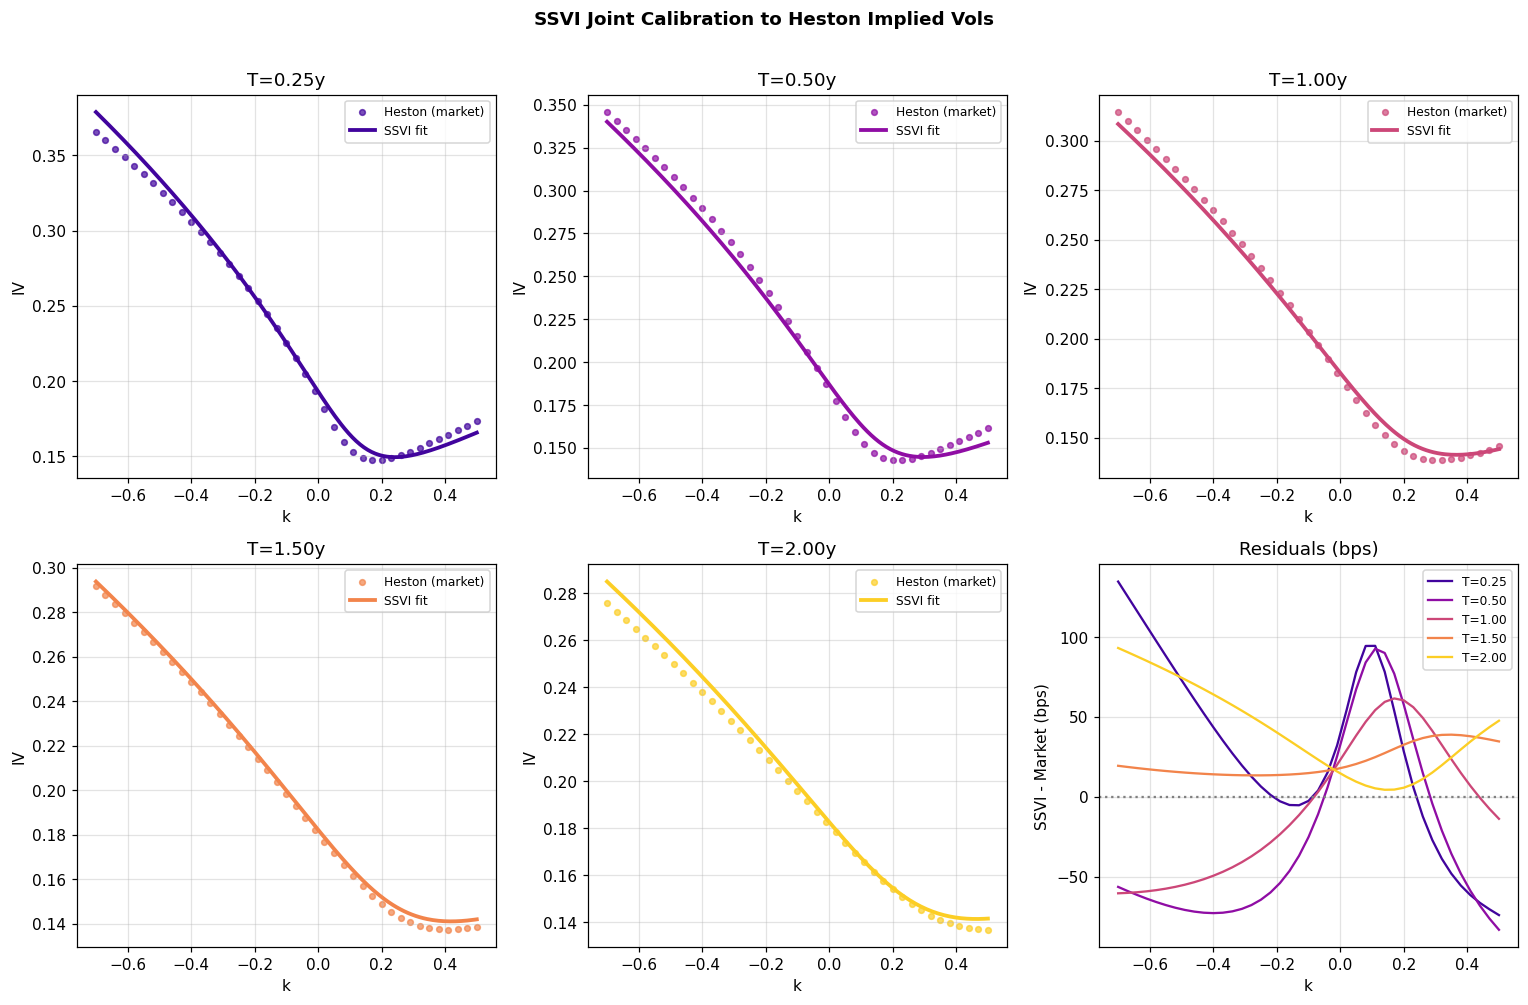

In [8]:
# Visualize SSVI fit vs Heston market
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(MATS_FIT)))

for i, (T, th, c) in enumerate(zip(MATS_FIT, ssvi_result.theta_t, colors)):
    ax = axes[i]
    k_i, iv_i = k_clean[i], iv_clean[i]
    k_fine = np.linspace(k_arr_fit[0], k_arr_fit[-1], 200)
    iv_fit = ssvi_implied_vol(k_fine, T, th, ssvi_result.params)
    ax.scatter(k_i, iv_i, s=14, color=c, alpha=0.7, label='Heston (market)')
    ax.plot(k_fine, iv_fit, color=c, lw=2.5, label='SSVI fit')
    ax.set(title=f'T={T:.2f}y', xlabel='k', ylabel='IV')
    ax.legend(fontsize=8)

# Residuals
ax = axes[5]
for i, (T, th, c) in enumerate(zip(MATS_FIT, ssvi_result.theta_t, colors)):
    k_i, iv_i = k_clean[i], iv_clean[i]
    iv_fit_at_k = ssvi_implied_vol(k_i, T, th, ssvi_result.params)
    ax.plot(k_i, (iv_fit_at_k - iv_i) * 1e4, color=c, lw=1.5, label=f'T={T:.2f}')
ax.axhline(0, ls=':', color='gray')
ax.set(title='Residuals (bps)', xlabel='k', ylabel='SSVI - Market (bps)')
ax.legend(fontsize=8)

fig.suptitle('SSVI Joint Calibration to Heston Implied Vols', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. SSVI vs. SVI (Per-Smile) Comparison

SVI fits each maturity independently; SSVI fits all maturities jointly under a joint constraint on phi. SSVI has fewer degrees of freedom (3 surface parameters vs. 5 per smile) but guarantees term-structure consistency.

In [9]:
# Fit per-smile SVI at each maturity
svi_fits = []
for i, T in enumerate(MATS_FIT):
    k_i, iv_i = k_clean[i], iv_clean[i]
    svi_fits.append(fe.fit_svi_smile(k_i, iv_i, T))
    print(f'T={T:.2f}: SVI RMSE={svi_fits[-1].rmse*1e4:.2f}bp  bf_free={svi_fits[-1].butterfly_free}')

print(f'\nSSVI global RMSE: {ssvi_result.rmse*1e4:.2f}bp  (all maturities)')

T=0.25: SVI RMSE=14.68bp  bf_free=True
T=0.50: SVI RMSE=8.88bp  bf_free=True
T=1.00: SVI RMSE=2.25bp  bf_free=True
T=1.50: SVI RMSE=0.32bp  bf_free=True
T=2.00: SVI RMSE=0.14bp  bf_free=True

SSVI global RMSE: 50.03bp  (all maturities)


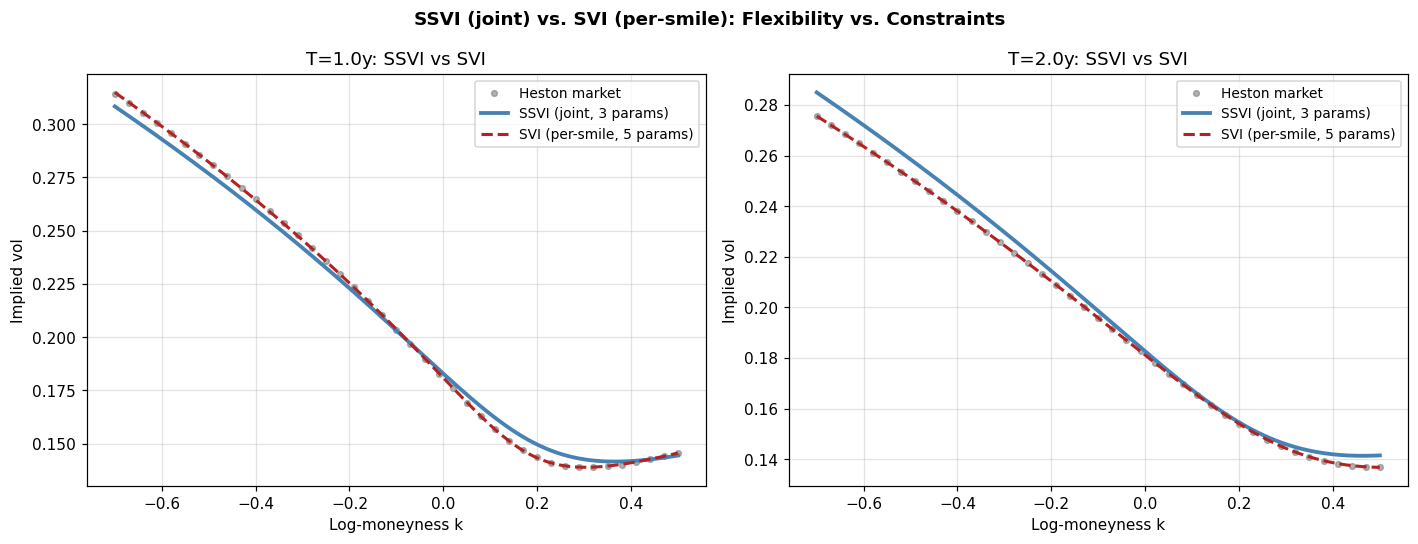

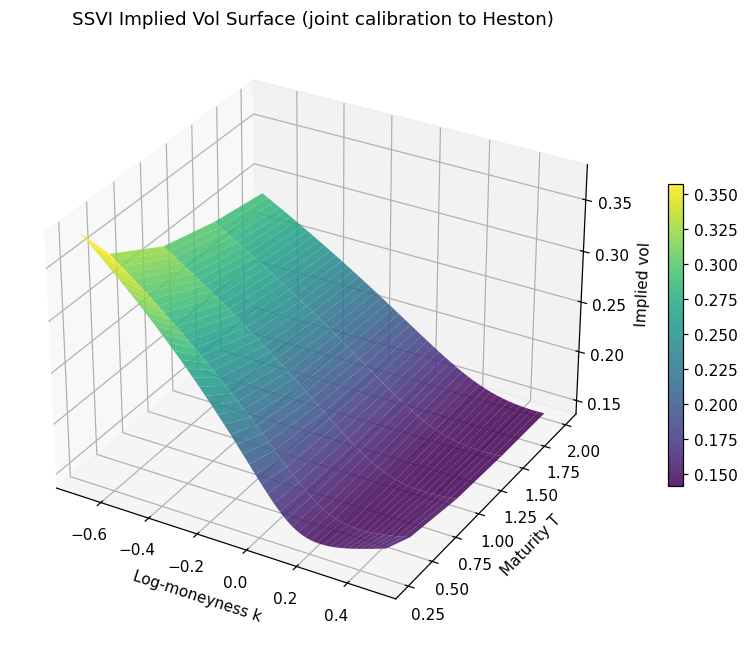

In [10]:
# Side-by-side: SSVI vs SVI for T=1y and T=2y
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_ssvi = ['steelblue', 'steelblue']
colors_svi  = ['firebrick', 'firebrick']

for col_idx, T_sel in enumerate([1.0, 2.0]):
    idx = list(MATS_FIT).index(T_sel)
    k_i, iv_i = k_clean[idx], iv_clean[idx]
    th = ssvi_result.theta_t[idx]
    k_fine = np.linspace(k_arr_fit[0], k_arr_fit[-1], 200)

    # SSVI
    iv_ssvi = ssvi_implied_vol(k_fine, T_sel, th, ssvi_result.params)
    # SVI
    iv_svi  = fe.svi_implied_vol(k_fine, T_sel, svi_fits[idx].params)

    ax = axes[col_idx]
    ax.scatter(k_i, iv_i, s=14, color='gray', alpha=0.6, label='Heston market')
    ax.plot(k_fine, iv_ssvi, color='steelblue', lw=2.5, label='SSVI (joint, 3 params)')
    ax.plot(k_fine, iv_svi, color='firebrick', lw=2, ls='--', label='SVI (per-smile, 5 params)')
    ax.set(title=f'T={T_sel:.1f}y: SSVI vs SVI', xlabel='Log-moneyness k', ylabel='Implied vol')
    ax.legend(fontsize=9)

fig.suptitle('SSVI (joint) vs. SVI (per-smile): Flexibility vs. Constraints', fontweight='bold')
plt.tight_layout()
plt.show()

# 3D surface view
fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111, projection='3d')
K_mg, T_mg = np.meshgrid(np.linspace(-0.7, 0.5, 50), MATS_FIT)
IV_mg = np.array([
    [ssvi_implied_vol(np.array([k]), T, ssvi_result.theta_t[i], ssvi_result.params)[0]
     for k in np.linspace(-0.7, 0.5, 50)]
    for i, T in enumerate(MATS_FIT)
])
surf = ax.plot_surface(K_mg, T_mg, IV_mg, cmap='viridis', alpha=0.85)
ax.set(title='SSVI Implied Vol Surface (joint calibration to Heston)',
       xlabel='Log-moneyness k', ylabel='Maturity T', zlabel='Implied vol')
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.tight_layout()
plt.show()